# Homografía y Proyección de Cancha

```text
Imagen de cámara (oblicua)
            │
            ▼
4 puntos del campo  →  H = cv2.getPerspectiveTransform()
            │
            ▼
┌──────────────────────────────────────────────────────┐
│  cv2.warpPerspective()       → Vista cenital cancha   │
│  cv2.perspectiveTransform()  → Posiciones robots 2D   │
└──────────────────────────────────────────────────────┘
            │
            ▼
Mapa táctico (estilo transmisión deportiva)
```

**Aprenderás a:**
- Entender qué es una homografía y cómo se representa como matriz 3×3.
- Calcular la transformación con `cv2.getPerspectiveTransform`.
- Transformar toda la imagen con `cv2.warpPerspective` (vista cenital).
- Proyectar coordenadas de puntos con `cv2.perspectiveTransform` (mapa táctico).
- Aplicar la homografía a video con `sv.process_video`.

## Setup · assets del curso

Este notebook usa una imagen y un video de la cancha robótica (`futbot-01.jpg`,
`futbot-2s.mp4`). El link de descarga del curso **está caído**, así que los assets se
colocan **manualmente** en la carpeta `assets/` del repo (ya están ahí).

La celda de abajo solo **verifica** que existan, resolviendo la ruta contra
`PROJECT_ROOT` para no depender del directorio de trabajo del kernel.

In [1]:
# Verificación de assets (el link de descarga del curso está caído).
# `src` es paquete editable -> este import funciona desde cualquier cwd.
from pathlib import Path

from src.utils import PROJECT_ROOT

ASSETS_DIR = PROJECT_ROOT / "assets"
IMG_PATH = ASSETS_DIR / "futbot-01.jpg"
VIDEO_PATH = ASSETS_DIR / "futbot-2s.mp4"

faltan = [p.name for p in (IMG_PATH, VIDEO_PATH) if not (p.exists() and p.stat().st_size > 0)]
assert not faltan, (
    f"Faltan assets en {ASSETS_DIR}: {faltan}. El link del curso está caído; "
    "colócalos manualmente en esa carpeta."
)
print("\u2713 assets encontrados en", ASSETS_DIR)
for pth in (IMG_PATH, VIDEO_PATH):
    print(f"   - {pth.name} ({pth.stat().st_size/1e6:.2f} MB)")

✓ assets encontrados en /mnt/datos/code/ai/futbot/assets
   - futbot-01.jpg (0.24 MB)
   - futbot-2s.mp4 (2.87 MB)


## ¿Qué es la homografía?

Imagina que tienes una foto del campo robótico tomada desde un ángulo — no perfectamente
desde arriba. Las líneas del campo que en la realidad son paralelas aparecen convergentes
en la foto.

La **homografía** es la "receta" matemática para corregir esa distorsión. Con solo
**4 pares de puntos correspondientes** — 4 esquinas del campo en la foto y sus posiciones
reales en el campo canónico — calculamos una transformación que "endereza" cualquier
punto o imagen.

```text
      MUNDO REAL                  IMAGEN DE CÁMARA
   ┌──────────────┐                ╱────────────╲
   │              │               ╱              ╲
   │    CAMPO     │   ───────►   │     CAMPO      │
   │              │               ╲              ╱
   └──────────────┘                ╲────────────╱
     Rectángulo             Trapecio (perspectiva de cámara)
```

Esa transformación — de trapecio a rectángulo — es lo que calcula la homografía.

## La matriz H (3×3) — sin álgebra

La homografía se representa como una matriz de 3×3 números. No necesitas entender cada
elemento; lo importante es lo que hace:

```text
H = [[h00, h01, h02],    aplicada a cualquier punto (x, y) de cámara:
     [h10, h11, h12],    → produce su nuevo (x', y') en el campo canónico
     [h20, h21, h22]]
```

Las tres operaciones clave:

| Función | Input | Output |
|---|---|---|
| `cv2.getPerspectiveTransform(src, dst)` | 4 pares de puntos | matriz H (3×3) |
| `cv2.warpPerspective(imagen, H, tamaño)` | imagen completa | imagen transformada |
| `cv2.perspectiveTransform(puntos, H)` | array de puntos | puntos transformados |

> **¿Cuándo usar cada una?**
> - `warpPerspective` transforma **toda la imagen** — útil para la vista cenital.
> - `perspectiveTransform` transforma **solo coordenadas de puntos** — útil para el mapa
>   táctico (mucho más rápido).

En este notebook calculas `H` **una sola vez** (la cámara es fija) y la reutilizas para
cada frame.

Imagen: 600×1080 px


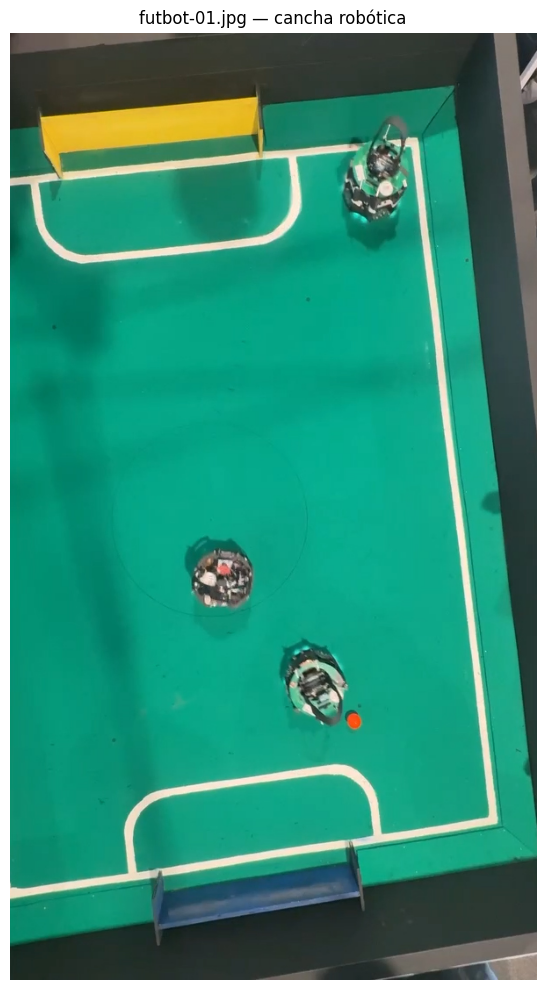

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import supervision as sv

# Cargar imagen de la cancha robótica
image_bgr = cv2.imread(str(IMG_PATH))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Imagen: {image_bgr.shape[1]}×{image_bgr.shape[0]} px")
plt.figure(figsize=(5.6, 10))
plt.imshow(image_rgb)
plt.title("futbot-01.jpg — cancha robótica")
plt.axis("off")
plt.tight_layout()
plt.show()

## Paso 1 — Definir los 4 puntos del campo

Para calcular `H` necesitamos exactamente 4 pares de puntos:

- `SOURCE_POINTS`: las 4 esquinas del campo en la **imagen de cámara** (en píxeles).
- `TARGET_POINTS`: las 4 esquinas del campo en el **espacio canónico** (el campo "plano").

El **orden importa**: el punto 1 de SOURCE corresponde al punto 1 de TARGET.

```text
   SOURCE (cámara, trapecio)          TARGET (campo canónico W×H)
        1 ──────────── 2             (0,0) ──────────── (W,0)
         ╲            ╱                 │                │
          ╲          ╱     ───────►     │     W × H      │
           ╲        ╱                   │                │
        4 ──────────── 3             (0,H) ──────────── (W,H)
```

Los `SOURCE_POINTS` fueron detectados automáticamente con OpenCV sobre `futbot-01.jpg`.

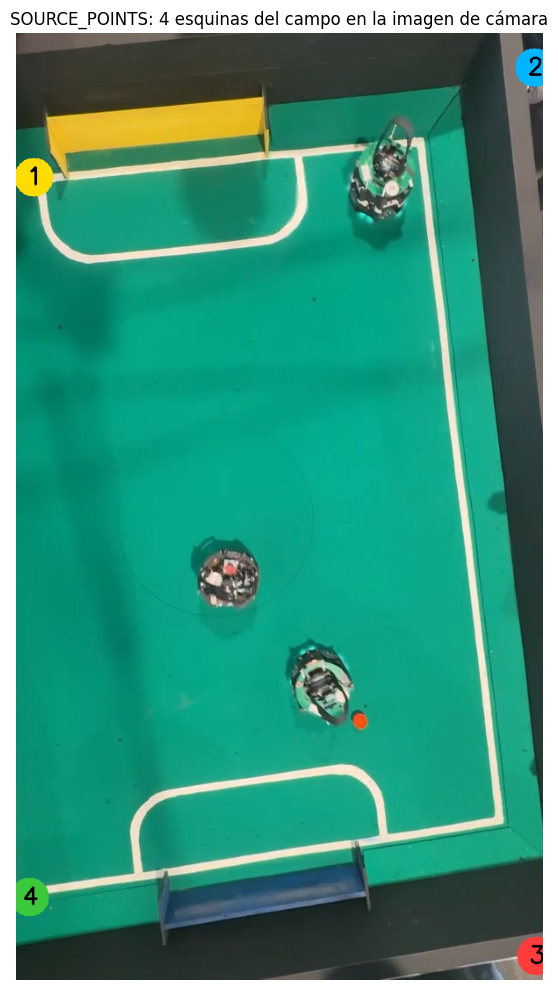

In [3]:
# Esquinas del campo detectadas con OpenCV (orden: TL, TR, BR, BL)
SOURCE_POINTS = np.float32(
    [
        [20, 165],  # 1 — esquina superior-izquierda
        [590, 40],  # 2 — esquina superior-derecha
        [592, 1052],  # 3 — esquina inferior-derecha
        [15, 985],  # 4 — esquina inferior-izquierda
    ]
)

# Campo canónico: 364 × 486 px  →  RCJ Soccer Field 2023 (182 × 243 cm) a 2 px/cm
# Arriba = portería amarilla | Abajo = portería azul
CAMPO_W, CAMPO_H = 364, 486
ESCALA_PX_CM = 2.0  # 1 cm real = 2 px en el campo canónico
TARGET_POINTS = np.float32(
    [
        [0, 0],  # 1 → TL canónico
        [CAMPO_W, 0],  # 2 → TR canónico
        [CAMPO_W, CAMPO_H],  # 3 → BR canónico
        [0, CAMPO_H],  # 4 → BL canónico
    ]
)

# Verificación visual: pinta los 4 puntos numerados sobre la imagen
PUNTO_COLORS = [(255, 220, 0), (0, 180, 255), (255, 60, 60), (60, 200, 60)]
vis = image_rgb.copy()
for idx, (pt, color) in enumerate(zip(SOURCE_POINTS, PUNTO_COLORS)):
    x, y = int(pt[0]), int(pt[1])
    cv2.circle(vis, (x, y), 22, color, -1)
    cv2.putText(
        vis, str(idx + 1), (x - 8, y + 8), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2
    )

plt.figure(figsize=(5.6, 10))
plt.imshow(vis)
plt.title("SOURCE_POINTS: 4 esquinas del campo en la imagen de cámara")
plt.axis("off")
plt.tight_layout()
plt.show()

## Pausa y observa: ¿por qué exactamente 4 puntos?

La perspectiva tiene **4 grados de libertad** (cuatro "parámetros independientes" que
distorsionan la imagen). Para determinarlos necesitamos exactamente 4 correspondencias.

| Nº de puntos | Transformación posible | ¿Corrige perspectiva? |
|---|---|---|
| 2 | Solo traslación + rotación | No |
| 3 | Transformación afín (preserva paralelas) | No |
| 4 | Homografía completa | Sí |
| > 4 | Ajuste por mínimos cuadrados (`findHomography`) | Sí (robusto a ruido) |

En este notebook usamos `getPerspectiveTransform` (exactamente 4 puntos) porque los
detectamos directamente sobre la imagen real — son precisos.

In [4]:
# Calcular la homografía a partir de los 4 pares de puntos
H = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)

# H_vis: misma homografía pero con MARGEN de contexto fuera del campo
# Los robots cerca del borde no se cortan en la visualización
MARGEN = 20  # px de buffer alrededor de los corners
CANVAS_W = CAMPO_W + 2 * MARGEN  # 404 px
CANVAS_H = CAMPO_H + 2 * MARGEN  # 526 px
H_vis = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS + MARGEN)

print("Matriz H (3×3):")
print("─" * 48)
for row in H:
    print("  " + "  ".join(f"{v:12.5f}" for v in row))
print("─" * 48)
print(f"\nTipo: {H.dtype}  |  Shape: {H.shape}")

Matriz H (3×3):
────────────────────────────────────────────────
       0.79721       0.00486     -16.74619
       0.13312       0.60704    -102.82470
       0.00042       0.00002       1.00000
────────────────────────────────────────────────

Tipo: float64  |  Shape: (3, 3)


## Mejora: findHomography + RANSAC

`getPerspectiveTransform` usa exactamente 4 puntos y los acepta todos sin cuestionar. Si
uno tiene un error de medición, ese error contamina toda la homografía.

`cv2.findHomography` con **RANSAC** resuelve esto: acepta N > 4 puntos, identifica
automáticamente los puntos con error (**outliers**) y calcula `H` usando solo los
confiables (**inliers**).

| Función | Puntos mínimos | Robustez a ruido | Uso típico |
|---|---|---|---|
| `getPerspectiveTransform` | 4 exactos | Baja | Puntos medidos manualmente |
| `findHomography` + RANSAC | ≥ 4 | Alta | Correspondencias detectadas automáticamente |

**Estrategia:** usamos la `H` ya calculada para predecir 5 puntos interiores del campo en
la imagen de cámara → obtenemos 9 correspondencias en total.

In [5]:
# 5 puntos interiores del campo canónico
PUNTOS_INTERIOR_CANON = np.float32(
    [
        [CAMPO_W // 2, 0],  # centro borde superior
        [CAMPO_W // 2, CAMPO_H],  # centro borde inferior
        [0, CAMPO_H // 2],  # centro borde izquierdo
        [CAMPO_W, CAMPO_H // 2],  # centro borde derecho
        [CAMPO_W // 2, CAMPO_H // 2],  # centro geométrico
    ]
)

# Proyectar esos puntos al espacio de cámara con la H inversa
H_inv_est = np.linalg.inv(H)
PUNTOS_INTERIOR_CAM = cv2.perspectiveTransform(
    PUNTOS_INTERIOR_CANON.reshape(1, -1, 2), H_inv_est
).reshape(-1, 2)

# 9 correspondencias: 4 corners + 5 interiores
pts_cam_9 = np.vstack([SOURCE_POINTS, PUNTOS_INTERIOR_CAM])
pts_canon_9 = np.vstack([TARGET_POINTS, PUNTOS_INTERIOR_CANON])

H_rob, mask_inliers = cv2.findHomography(pts_cam_9, pts_canon_9, cv2.RANSAC, 3.0)
print(f"Inliers RANSAC: {int(mask_inliers.sum())}/{len(pts_cam_9)}")
print(f"Diferencia H vs H_rob (norma L2): {np.linalg.norm(H - H_rob):.6f}")
print(
    "(cercana a 0 = equivalentes con puntos precisos; H_rob es más robusta con ruido)"
)

Inliers RANSAC: 9/9
Diferencia H vs H_rob (norma L2): 0.000004
(cercana a 0 = equivalentes con puntos precisos; H_rob es más robusta con ruido)


## Sobre la matriz H

- Las dos primeras columnas codifican **rotación + escala + cizallamiento**.
- La tercera columna codifica la **perspectiva** — el factor que hace converger líneas
  paralelas.
- La última fila `[h20, h21, 1]` es lo que distingue a la homografía de una
  transformación afín: si `h20` y `h21` son 0, no habría corrección de perspectiva.

**Lo práctico:**
- `H` depende solo de los 4 puntos, no de la imagen. Calcúlala una vez y reutilízala.
- `H` es invertible: `H_inv = np.linalg.inv(H)` convierte de canónico → cámara.
- La misma `H` sirve para todos los frames del video (cámara fija).

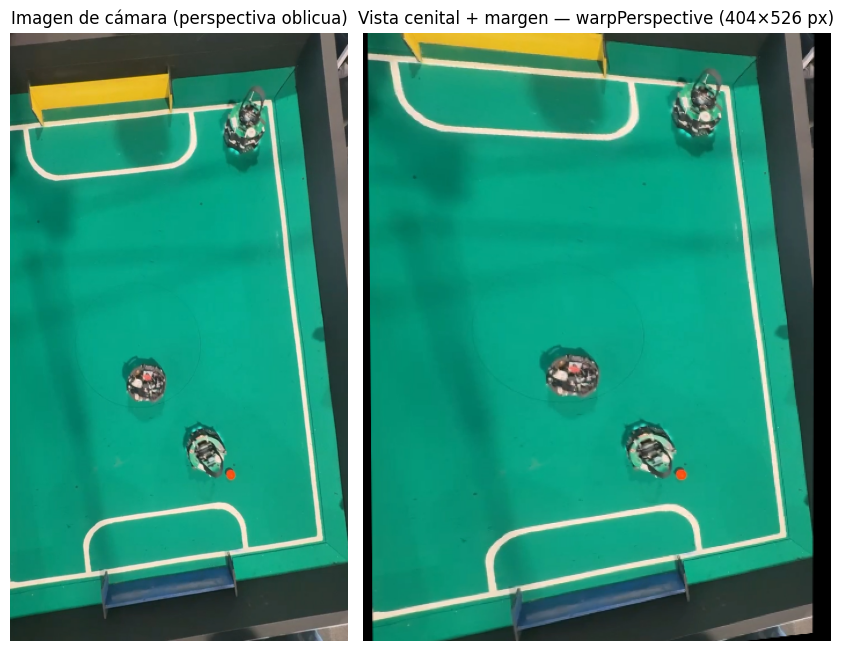

In [6]:
# Aplicar la homografía a toda la imagen
warped = cv2.warpPerspective(image_bgr, H_vis, (CANVAS_W, CANVAS_H))
warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.5, 7),
    gridspec_kw={"width_ratios": [600 / 1080, CANVAS_W / CANVAS_H]},
)
axes[0].imshow(image_rgb)
axes[0].set_title("Imagen de cámara (perspectiva oblicua)", fontsize=12)
axes[0].axis("off")
axes[1].imshow(warped_rgb)
axes[1].set_title(
    f"Vista cenital + margen — warpPerspective ({CANVAS_W}×{CANVAS_H} px)", fontsize=12
)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Paso 4 — Mapa táctico 2D

El warp de imagen es visualmente impactante, pero en análisis deportivo lo que importa es
un diagrama limpio con las posiciones de los jugadores.

```text
Posición robot en cámara (px)
            │  cv2.perspectiveTransform(punto, H)
            ▼
Posición en campo canónico (px)
            │  draw_tactical_map()   (matplotlib.patches + scatter)
            ▼
Mapa táctico estilo transmisión deportiva
```

En este notebook las posiciones de los robots están **hardcodeadas** (medidas sobre la
imagen). Más adelante aprenderás a obtenerlas automáticamente mediante detección de
objetos.

In [7]:
# Posiciones de robots y balón en coordenadas de cámara (píxeles)
# Equipo azul: R1, R2  |  Equipo rojo: R3
ROBOTS = {
    "R1": {"pos_cam": np.float32([[1100, 220]]), "color": "#00b4d8", "team": "azul"},
    "R2": {"pos_cam": np.float32([[840, 590]]), "color": "#00b4d8", "team": "azul"},
    "R3": {"pos_cam": np.float32([[1030, 800]]), "color": "#ef233c", "team": "rojo"},
}
BALL_CAM = np.float32([[870, 720]])


def project_point(pt_cam: np.ndarray, H: np.ndarray) -> tuple:
    """Proyecta un punto de coordenadas de cámara al campo canónico."""
    # perspectiveTransform requiere shape (N, 1, 2) con dtype float32
    projected = cv2.perspectiveTransform(pt_cam.reshape(1, 1, 2).astype(np.float32), H)
    return (int(projected[0][0][0]), int(projected[0][0][1]))


# Proyectar todos los robots y el balón
for name, data in ROBOTS.items():
    data["pos_canon"] = project_point(data["pos_cam"], H)
    cam = data["pos_cam"][0]
    print(
        f"{name} ({data['team']:4s}):  cámara ({cam[0]:.0f}, {cam[1]:.0f})  →  canónico {data['pos_canon']}"
    )

ball_canon = project_point(BALL_CAM, H)
print(
    f"Balón:          cámara ({BALL_CAM[0][0]:.0f}, {BALL_CAM[0][1]:.0f})  →  canónico {ball_canon}"
)

R1 (azul):  cámara (1100, 220)  →  canónico (588, 121)
R2 (azul):  cámara (840, 590)  →  canónico (482, 269)
R3 (rojo):  cámara (1030, 800)  →  canónico (560, 360)
Balón:          cámara (870, 720)  →  canónico (494, 327)


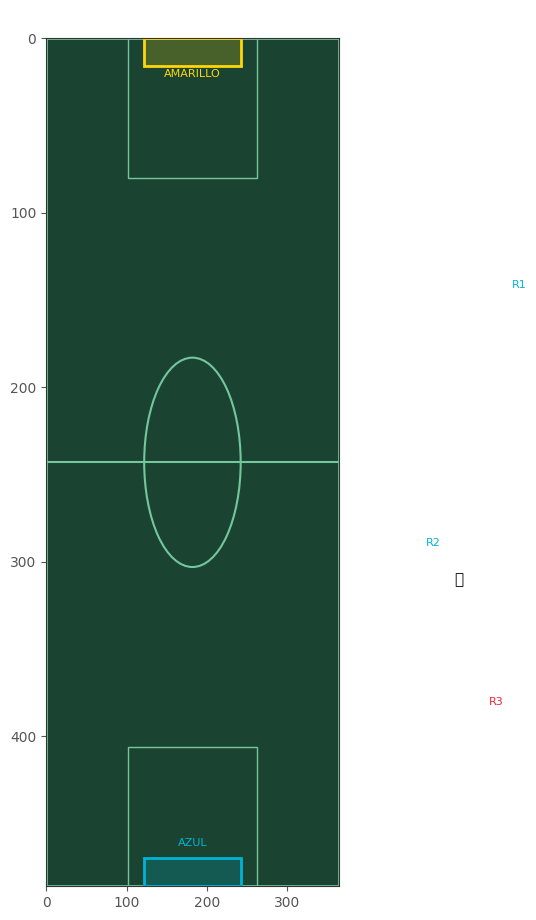

In [8]:
def draw_tactical_map(
    robots: dict,
    ball_canon: tuple,
    campo_w: int = CAMPO_W,
    campo_h: int = CAMPO_H,
    title: str = "Mapa táctico — deporte robótico",
) -> None:
    """Dibuja el campo canónico con robots y balón proyectados."""
    fig, ax = plt.subplots(figsize=(7, 9.3))
    ax.set_facecolor("#1b4332")
    ax.set_xlim(0, campo_w)
    ax.set_ylim(campo_h, 0)  # eje y invertido: 0 arriba, como coords de imagen

    # Borde del campo
    ax.add_patch(
        mpatches.Rectangle(
            (0, 0), campo_w, campo_h, lw=2, edgecolor="#74c69d", facecolor="none"
        )
    )
    # Línea central
    ax.axhline(y=campo_h / 2, color="#74c69d", lw=1.5)
    # Círculo central
    ax.add_patch(
        plt.Circle(
            (campo_w / 2, campo_h / 2),
            radius=int(30 * ESCALA_PX_CM),
            color="#74c69d",
            fill=False,
            lw=1.5,
        )
    )
    # Áreas de penalty  (RCJ SF23: ~80 cm ancho, ~40 cm profundidad)
    pen_w, pen_h = int(80 * ESCALA_PX_CM), int(40 * ESCALA_PX_CM)
    pen_x = (campo_w - pen_w) / 2
    for y_pen in (0, campo_h - pen_h):
        ax.add_patch(
            mpatches.Rectangle(
                (pen_x, y_pen),
                pen_w,
                pen_h,
                lw=1,
                edgecolor="#74c69d",
                facecolor="none",
            )
        )
    # Porterías  (RCJ SF23: ~60 cm ancho)
    goal_w = int(60 * ESCALA_PX_CM)
    goal_x = (campo_w - goal_w) / 2
    ax.add_patch(
        mpatches.Rectangle(
            (goal_x, 0),
            goal_w,
            int(8 * ESCALA_PX_CM),
            lw=2,
            edgecolor="#ffd60a",
            facecolor="#ffd60a33",
        )
    )
    ax.add_patch(
        mpatches.Rectangle(
            (goal_x, campo_h - int(8 * ESCALA_PX_CM)),
            goal_w,
            int(8 * ESCALA_PX_CM),
            lw=2,
            edgecolor="#00b4d8",
            facecolor="#00b4d833",
        )
    )
    ax.text(campo_w / 2, 22, "AMARILLO", color="#ffd60a", fontsize=8, ha="center")
    ax.text(
        campo_w / 2,
        campo_h - 22,
        "AZUL",
        color="#00b4d8",
        fontsize=8,
        ha="center",
        va="bottom",
    )

    # Robots
    for name, data in robots.items():
        x, y = data["pos_canon"]
        ax.scatter(
            x, y, s=350, c=data["color"], zorder=5, edgecolors="white", linewidths=1.5
        )
        ax.text(
            x,
            y,
            name[-1],
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white",
            zorder=6,
        )
        ax.text(x, y + 22, name, ha="center", color=data["color"], fontsize=8, zorder=6)

    # Balón
    bx, by = ball_canon
    ax.scatter(
        bx,
        by,
        s=180,
        c="#ff9500",
        zorder=5,
        edgecolors="white",
        linewidths=1.5,
        marker="o",
    )
    ax.text(bx + 14, by - 14, "⚽", fontsize=11, zorder=6)

    ax.set_title(title, fontsize=13, color="white", pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")
    ax.tick_params(colors="#555")
    plt.tight_layout()
    plt.show()


draw_tactical_map(ROBOTS, ball_canon)

🔧 Exploración interactiva

Tres experimentos para entender cómo reacciona la homografía a distintos cambios. En cada uno modificamos un solo parámetro mientras mantenemos el resto igual.


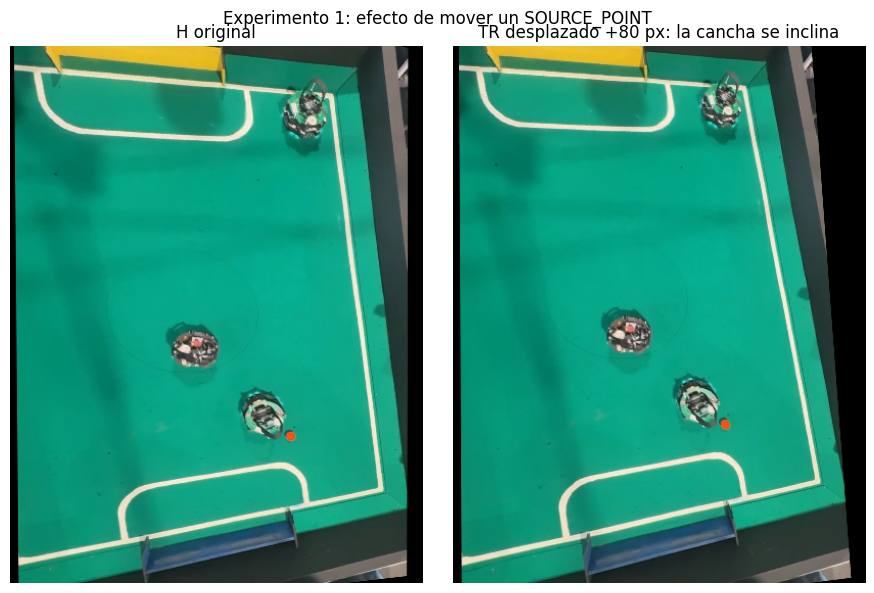

In [9]:
### Experimento 1: ¿Qué pasa si un SOURCE_POINT cambia de posición?

# Desplaza la esquina superior-derecha (TR) 80 px hacia la derecha
SOURCE_MOD = SOURCE_POINTS.copy()
SOURCE_MOD[1][0] += 80

H_mod = cv2.getPerspectiveTransform(SOURCE_MOD, TARGET_POINTS + MARGEN)
warped_mod = cv2.warpPerspective(image_bgr, H_mod, (CANVAS_W, CANVAS_H))

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
axes[0].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
axes[0].set_title("H original")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(warped_mod, cv2.COLOR_BGR2RGB))
axes[1].set_title("TR desplazado +80 px: la cancha se inclina")
axes[1].axis("off")
plt.suptitle("Experimento 1: efecto de mover un SOURCE_POINT", fontsize=12)
plt.tight_layout()
plt.show()

# 💭 Reflexión: ¿en qué dirección se inclinó la vista cenital?
# ¿Qué pasaría si mueves el punto en la dirección opuesta (-80 px)?

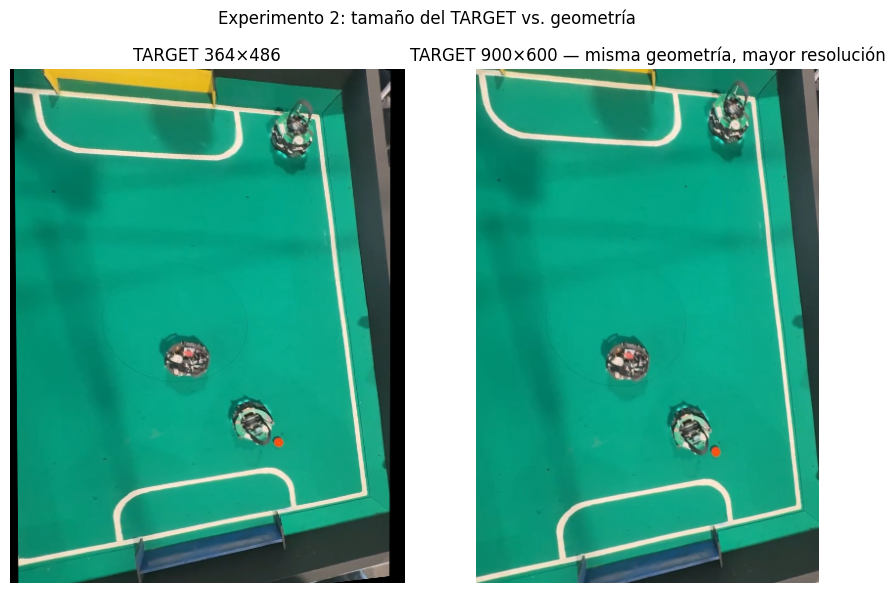

In [10]:
### Experimento 2: ¿Afecta el tamaño del TARGET a la geometría?

# Campo más grande: 900×600 en lugar de 600×400
TARGET_WIDE = np.float32([[0, 0], [600, 0], [600, 900], [0, 900]])
H_wide = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_WIDE)
warped_wide = cv2.warpPerspective(image_bgr, H_wide, (600, 900))

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
axes[0].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"TARGET {CAMPO_W}×{CAMPO_H}")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(warped_wide, cv2.COLOR_BGR2RGB))
axes[1].set_title("TARGET 900×600 — misma geometría, mayor resolución")
axes[1].axis("off")
plt.suptitle("Experimento 2: tamaño del TARGET vs. geometría", fontsize=12)
plt.tight_layout()
plt.show()

# 💭 Reflexión: compara las dos imágenes con atención.
# ¿Cambió la geometría (ángulos, proporciones) del campo entre los dos warps?
# ¿Qué controla entonces el tamaño del TARGET?

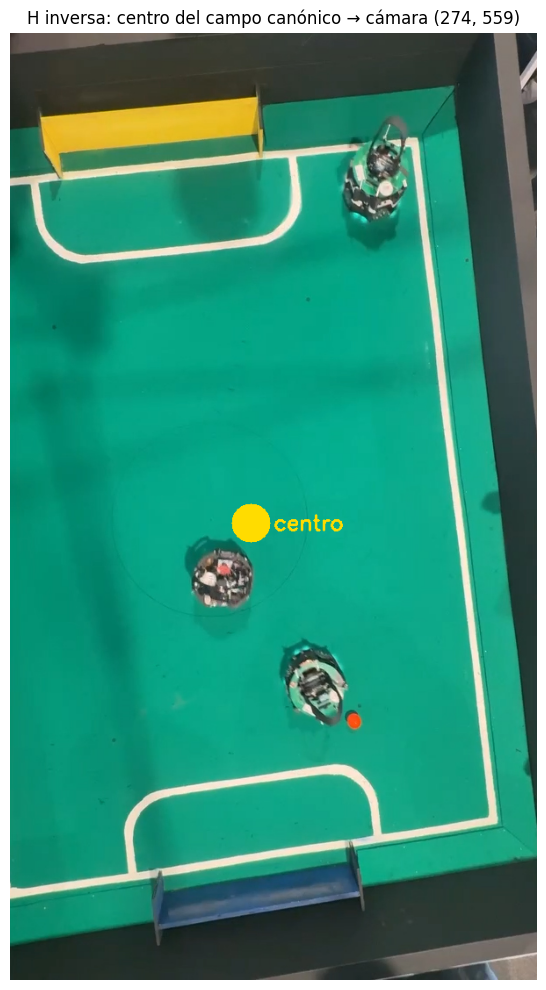

In [11]:
### Experimento 3: H inversa — de canónico a cámara

# La H inversa transforma coordenadas canónicas → coordenadas de cámara
H_inv = np.linalg.inv(H)

# ¿Dónde está el centro exacto del campo canónico en la imagen de cámara?
centro_canon = np.float32([[[CAMPO_W / 2, CAMPO_H / 2]]])
centro_cam = cv2.perspectiveTransform(centro_canon, H_inv)
cx, cy = int(centro_cam[0][0][0]), int(centro_cam[0][0][1])

vis_inv = image_rgb.copy()
cv2.circle(vis_inv, (cx, cy), 22, (255, 220, 0), -1)
cv2.putText(
    vis_inv,
    "centro",
    (cx + 26, cy + 8),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 220, 0),
    2,
)

plt.figure(figsize=(5.6, 10))
plt.imshow(vis_inv)
plt.title(f"H inversa: centro del campo canónico → cámara ({cx}, {cy})")
plt.axis("off")
plt.tight_layout()
plt.show()

# 💭 Reflexión: ¿coincide el punto amarillo con el círculo central de la cancha?
# Si hay una pequeña diferencia, ¿qué la explica?
# (Pista: los SOURCE_POINTS son las esquinas exteriores, no el marcador central)

## Paso 5 — Escala real: distancias y velocidades en cm

Con `ESCALA_PX_CM = 2.0` (1 cm real = 2 px en el campo canónico) podemos expresar
posiciones y velocidades en unidades físicas reales.

```text
posición robot A (px canónico) ─┐
                                ├─►  distancia (cm) = dist_px / ESCALA_PX_CM
posición robot B (px canónico) ─┘

distancia (cm) × fps = velocidad (cm/s)
```

Esto es posible gracias a que conocemos las dimensiones reales del campo
(RCJ Soccer Field 2023: 182 × 243 cm) y las codificamos en `ESCALA_PX_CM`.

In [12]:
def dist_cm(p1: tuple, p2: tuple, escala: float = ESCALA_PX_CM) -> float:
    """Distancia euclidiana entre dos puntos canónicos, en centímetros reales."""
    dx = (p2[0] - p1[0]) / escala
    dy = (p2[1] - p1[1]) / escala
    return float(np.sqrt(dx**2 + dy**2))


def speed_cm_s(
    p1: tuple, p2: tuple, fps: float = 30.0, escala: float = ESCALA_PX_CM
) -> float:
    """Velocidad entre dos posiciones consecutivas (cm/s)."""
    return dist_cm(p1, p2, escala) * fps


# Demo con los robots del mapa táctico
print(
    f"Campo canónico: {CAMPO_W}×{CAMPO_H} px  →  {CAMPO_W/ESCALA_PX_CM:.0f}×{CAMPO_H/ESCALA_PX_CM:.0f} cm real"
)
print()

r1_c = ROBOTS["R1"]["pos_canon"]
r2_c = ROBOTS["R2"]["pos_canon"]
r3_c = ROBOTS["R3"]["pos_canon"]

print(f"R1 → R2  : {dist_cm(r1_c, r2_c):.1f} cm")
print(f"R1 → R3  : {dist_cm(r1_c, r3_c):.1f} cm")
print(f"R2 → Balón: {dist_cm(r2_c, ball_canon):.1f} cm")
print()

# Simular movimiento del balón entre dos frames a 30 fps
ball_frame2 = (ball_canon[0] + 8, ball_canon[1] + 12)
v = speed_cm_s(ball_canon, ball_frame2, fps=30.0)
print(f"Balón se mueve 8 px (X) y 12 px (Y) entre frames consecutivos:")
print(f"  Velocidad estimada: {v:.1f} cm/s  ({v/100:.2f} m/s)")

Campo canónico: 364×486 px  →  182×243 cm real

R1 → R2  : 91.0 cm
R1 → R3  : 120.3 cm
R2 → Balón: 29.6 cm

Balón se mueve 8 px (X) y 12 px (Y) entre frames consecutivos:
  Velocidad estimada: 216.3 cm/s  (2.16 m/s)


## Aplicar la homografía al video

La cámara es fija: la matriz `H` calculada sobre la imagen estática es válida para todos
los frames del video.

Procesaremos `futbot-2s.mp4` (2 s, 48 frames @ 24fps) frame a frame con `sv.VideoSink`,
aplicando el warp a cada frame y concatenándolo con el original:

```text
┌──────────────────────────┬──────────────────┐
│ Frame original           │ Frame warped     │
│ (redimensionado)         │ (vista cenital)  │
└──────────────────────────┴──────────────────┘
```

> Usamos `VideoSink` (y no `sv.process_video`) porque el frame **compuesto** cambia de
> tamaño respecto a la fuente; `process_video` fija la salida al tamaño del video de
> entrada y produciría un mp4 vacío. Con `VideoSink` declaramos el tamaño real del
> compuesto.

In [13]:
# El mp4 generado es pesado -> va a outputs/ (git-ignored), no a assets/ (versionado).
_out_dir = PROJECT_ROOT / "outputs" / "fase3_homografia"
_out_dir.mkdir(parents=True, exist_ok=True)
OUTPUT_VIDEO = str(_out_dir / "futbot_homografia.mp4")

src_info = sv.VideoInfo.from_video_path(str(VIDEO_PATH))

# Dimensiones del frame compuesto (cámara redimensionada | cenital con margen).
escala = CANVAS_H / src_info.height
orig_w = int(src_info.width * escala)
COMP_W, COMP_H = orig_w + CANVAS_W, CANVAS_H
out_info = sv.VideoInfo(width=COMP_W, height=COMP_H, fps=src_info.fps)


def componer(frame: np.ndarray) -> np.ndarray:
    warped_frame = cv2.warpPerspective(frame, H_vis, (CANVAS_W, CANVAS_H))
    resized = cv2.resize(frame, (orig_w, CANVAS_H))  # misma altura que el warp
    return np.hstack([resized, warped_frame])         # cámara | cenital


with sv.VideoSink(OUTPUT_VIDEO, video_info=out_info) as sink:
    for frame in sv.get_video_frames_generator(str(VIDEO_PATH)):
        sink.write_frame(componer(frame))

print(f"\u2705 Video guardado: {OUTPUT_VIDEO}  ({COMP_W}\u00d7{COMP_H})")

✅ Video guardado: /mnt/datos/code/ai/futbot/outputs/fase3_homografia/futbot_homografia.mp4  (696×526)


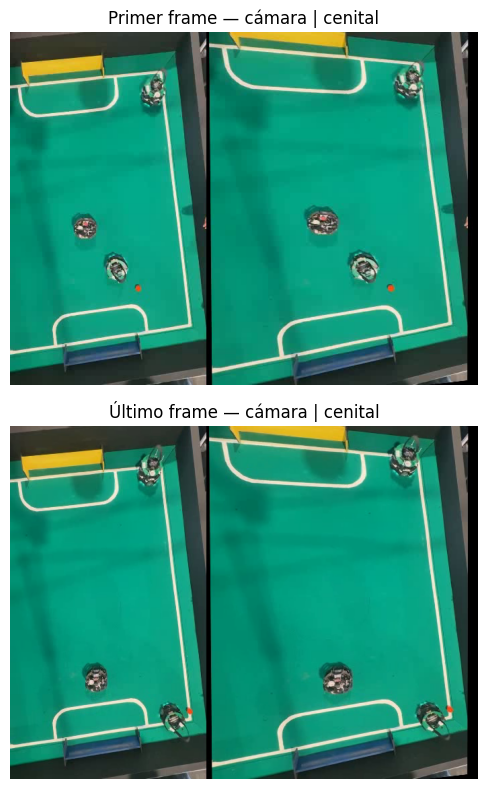

In [14]:
# Mostrar primer y último frame del video de salida
cap = cv2.VideoCapture(OUTPUT_VIDEO)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frames_vis = {}
for idx in (0, n_frames - 1):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frames_vis[idx] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
cap.release()

# Calcular figsize dinámicamente para respetar el aspecto del frame compuesto
_sample = next(iter(frames_vis.values()))
_h, _w = _sample.shape[:2]
_dh = 4
fig, axes = plt.subplots(
    len(frames_vis), 1, figsize=(_dh * _w / _h, _dh * len(frames_vis))
)
for ax, (idx, frgb) in zip(axes, frames_vis.items()):
    ax.imshow(frgb)
    ax.set_title(
        "Primer frame — cámara | cenital"
        if idx == 0
        else "Último frame — cámara | cenital"
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

Exploración visual — demo interactiva de perspectiva

Abre el siguiente archivo en tu navegador para ver cómo cambia la perspectiva del campo al mover los deslizadores (ángulo de cámara, distancia focal):

→ `<repo>/assets/homografia_interactiva.html`

La demo tiene dos paneles y tres deslizadores: - Ángulo de cámara y distancia focal — simulan una cámara en distintas posiciones. - Panel izquierdo — muestra el trapecio que ve la cámara (como SOURCE_POINTS). - Panel derecho — muestra la vista cenital (como cv2.warpPerspective).

Mueve los deslizadores y observa: sin importar cuánto inclines la cámara, el panel derecho siempre aparece rectangular. Eso es exactamente lo que hace la homografía.


## 🚀 Reto resuelto — Selector interactivo de puntos

En este notebook los `SOURCE_POINTS` están hardcodeados para `futbot-01.jpg`. Si tienes
una cámara diferente o cambias el ángulo, necesitas recalcular los 4 puntos manualmente.

La función `select_field_corners()` resuelve esto de forma interactiva: haces clic en las
4 esquinas directamente sobre la imagen en el notebook y obtienes los puntos listos para
reemplazar los hardcodeados.

> ⚠️ Requiere `ipywidgets`. Si no lo tienes, ejecuta primero:
> ```bash
> pip install ipywidgets
> ```
> Luego descomenta `# %matplotlib widget` en la celda de abajo y reinicia el kernel.

In [15]:
# %matplotlib widget   ← descomenta esta línea para activar el modo interactivo


def select_field_corners(image_rgb: np.ndarray, n: int = 4) -> np.ndarray | None:
    """
    Selector interactivo: haz clic en las n esquinas del campo.
    Orden recomendado: TL → TR → BR → BL (siguiendo las agujas del reloj).

    Retorna np.float32 con shape (n, 2) listo para usar como SOURCE_POINTS,
    o None si no se completaron los n clics.
    """
    puntos = []
    fig, ax = plt.subplots(figsize=(5.6, 10))
    ax.imshow(image_rgb)
    ax.set_title(
        f"Haz clic en {n} esquinas (TL → TR → BR → BL)\n" f"Seleccionados: 0 / {n}",
        fontsize=11,
    )
    ax.axis("off")
    (linea,) = ax.plot([], [], "o-", color="#ffd60a", markersize=12, linewidth=2)

    def on_click(event):
        if event.inaxes != ax or len(puntos) >= n:
            return
        puntos.append([event.xdata, event.ydata])
        xs = [p[0] for p in puntos]
        ys = [p[1] for p in puntos]
        if len(puntos) == n:  # cerrar el polígono
            xs.append(puntos[0][0])
            ys.append(puntos[0][1])
        linea.set_data(xs, ys)
        ax.text(
            event.xdata + 10,
            event.ydata - 10,
            str(len(puntos)),
            color="#ffd60a",
            fontsize=13,
            fontweight="bold",
            zorder=5,
        )
        ax.set_title(
            f"Haz clic en {n} esquinas (TL → TR → BR → BL)\n"
            f"Seleccionados: {len(puntos)} / {n}",
            fontsize=11,
        )
        fig.canvas.draw()
        if len(puntos) == n:
            print("✅ Puntos capturados:")
            for i, p in enumerate(puntos, 1):
                print(f"   {i}: ({p[0]:.0f}, {p[1]:.0f})")

    fig.canvas.mpl_connect("button_press_event", on_click)
    plt.tight_layout()
    plt.show()
    return np.float32(puntos) if len(puntos) == n else None

In [16]:
# DEMO: cómo usar select_field_corners con tu propia imagen
# Descomenta el bloque para ejecutar el selector interactivo:

# %matplotlib widget
# SOURCE_INTERACTIVO = select_field_corners(image_rgb)
#
# if SOURCE_INTERACTIVO is not None:
#     H_nuevo     = cv2.getPerspectiveTransform(SOURCE_INTERACTIVO, TARGET_POINTS)
#     warped_nuevo = cv2.warpPerspective(image_bgr, H_nuevo, (CAMPO_W, CAMPO_H))
#
#     fig, axes = plt.subplots(1, 2, figsize=(8.5, 7),
#                            gridspec_kw={"width_ratios": [600/1080, 364/486]})
#     axes[0].imshow(image_rgb)
#     axes[0].set_title("Original con tus puntos")
#     axes[0].axis("off")
#     axes[1].imshow(cv2.cvtColor(warped_nuevo, cv2.COLOR_BGR2RGB))
#     axes[1].set_title("Vista cenital con tus puntos")
#     axes[1].axis("off")
#     plt.tight_layout()
#     plt.show()

# Verificación: la función está definida y es callable
print("✅ select_field_corners está lista para usar.")
print("   Descomenta el bloque de arriba para ejecutar el selector interactivo.")

✅ select_field_corners está lista para usar.
   Descomenta el bloque de arriba para ejecutar el selector interactivo.


## Cierre del notebook

**Lo que construiste:**
- Homografía calculada con `cv2.getPerspectiveTransform` a partir de 4 esquinas reales
  del campo.
- Vista cenital de la cancha robótica con `cv2.warpPerspective`.
- Mapa táctico 2D con posiciones de robots y balón proyectadas con
  `cv2.perspectiveTransform`.
- Pipeline de video con `sv.process_video` que aplica `H` a cada frame (cámara fija).
- Selector interactivo de puntos para adaptar la `H` a cualquier cámara o ángulo.

**Lo que viene:**

| Notebook | Qué agrega sobre este |
|---|---|
| `03` — Detección + Homografía | un detector localiza los robots automáticamente → sus posiciones se proyectan con la misma `H` |
| `04` — SAM + Homografía | SAM obtiene máscaras de los robots → se proyectan al mapa con mayor detalle visual |

La homografía (este notebook) se reutiliza **sin cambios** en los siguientes notebooks.
Solo cambia **cómo se obtienen los puntos a proyectar**.